In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt
import requests
import re

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

print(text[:500])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:

text = text.lower()


text = re.sub(r'[^a-z\s]', '', text)


words = text.split()

print("Total words:", len(words))

Total words: 202619


In [4]:
vocab = sorted(set(words))

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print("Vocabulary size:", len(vocab))

Vocabulary size: 12847


In [5]:
encoded = [word2idx[w] for w in words]

In [6]:
sequence_length = 5

X = []
y = []

for i in range(len(encoded) - sequence_length):
    X.append(encoded[i:i+sequence_length])
    y.append(encoded[i+sequence_length])

X = np.array(X)
y = np.array(y)

print("Input shape:", X.shape)

Input shape: (202614, 5)


In [7]:
model = Sequential([
    Embedding(input_dim=len(vocab), output_dim=50, input_length=sequence_length),
    SimpleRNN(100),
    Dense(len(vocab), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(X, y, epochs=5, batch_size=128)

Epoch 1/5
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 115s 71ms/step - loss: 6.7485
Epoch 2/5
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 141s 70ms/step - loss: 6.1595
Epoch 3/5
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 112s 71ms/step - loss: 5.8682
Epoch 4/5
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 111s 70ms/step - loss: 5.6342
Epoch 5/5
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 143s 71ms/step - loss: 5.4275


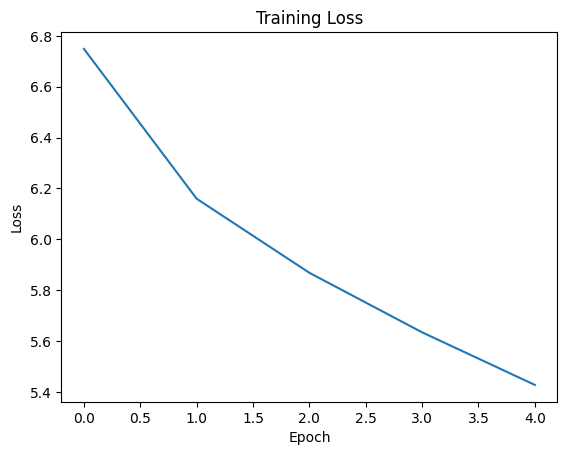

In [9]:
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [10]:
import random

def generate_text(seed_text, next_words=10):
    result = seed_text.split()

    for _ in range(next_words):
        encoded_seed = [word2idx.get(w, 0) for w in result[-sequence_length:]]
        encoded_seed = np.array(encoded_seed).reshape(1, -1)

        predicted = model.predict(encoded_seed, verbose=0)
        predicted_word = idx2word[np.argmax(predicted)]

        result.append(predicted_word)

    return " ".join(result)

print(generate_text("to be or not to", 10))

to be or not to the king and not the king and all the sun
